In [ ]:
# Autoreload para refletir mudanças no config sem reiniciar kernel
%load_ext autoreload
%autoreload 2

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import logging

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
from churn_telecom.config import get_logger
logger = get_logger("0.04_eda_multivariate")

In [ ]:
# Célula 3 — módulo interno do projeto
from churn_telecom.config import (
    COLS_CAT,
    COLS_NUM,
    DATA_INTERIM,
    REPORTS_FIGURES,
    CORES,
    TARGET,
)

In [ ]:
# Célula 5 — carrega dados
df = pd.read_parquet(DATA_INTERIM / "telco_typed.parquet")
logger.info("Dataset carregado. Shape: %s", df.shape)
df.head()

Dataset carregado. Shape: (7043, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [ ]:
# Célula 6 — garante que o diretório de saída existe
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

Iniciando análise de correlação e multicolinearidade.


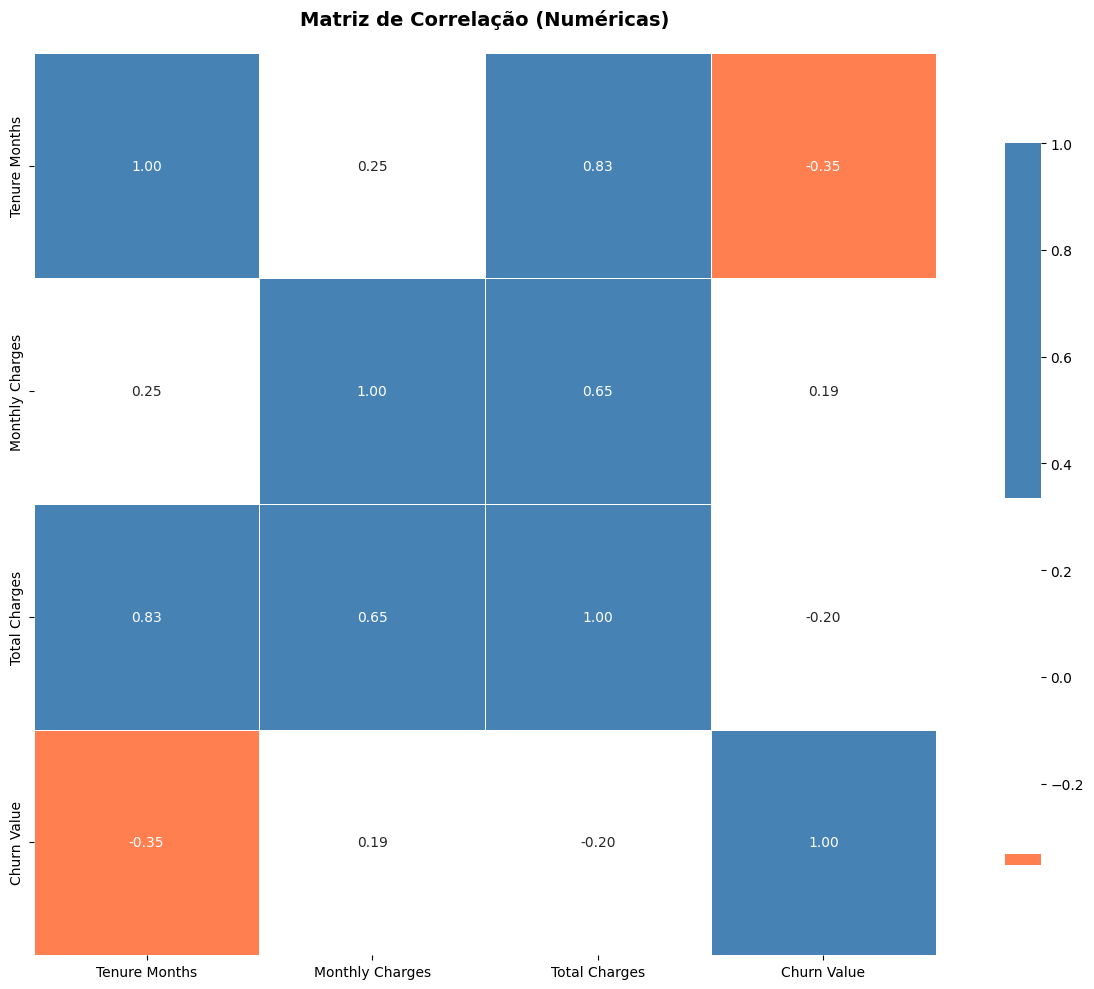

Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\correlation_matrix_numeric.png
=== CORRELAÇÕES COM TARGET ===
Monthly Charges | corr_target=0.1934
Total Charges | corr_target=-0.1995
Tenure Months | corr_target=-0.3522
=== ANÁLISE DE MULTICOLINEARIDADE (CORR) ===
Foram encontrados 1 pares com correlação >= 0.70
HIGH_CORR | Tenure Months vs Total Charges | corr=0.8259
=== ANÁLISE DE VIF (MULTICOLINEARIDADE AVANÇADA) ===
Total Charges | VIF=8.0792
Tenure Months | VIF=6.3324
Monthly Charges | VIF=3.3611
Tabela de VIF salva em: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\vif_table.csv
Análise de correlação e multicolinearidade finalizada.


In [ ]:
logger.info("Iniciando análise de correlação e multicolinearidade.")


# ── Seleção de variáveis numéricas ─────────────────────────────────────
df_num = df.select_dtypes(include=[np.number]).copy()

if TARGET not in df_num.columns:
    logger.warning("TARGET '%s' não está entre variáveis numéricas.", TARGET)

# ── Matriz de correlação ───────────────────────────────────────────────
corr_matrix = df_num.corr()

# ── Plot heatmap ───────────────────────────────────────────────────────
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(
        [CORES["destaque"], "white", CORES["secundaria"]],
        as_cmap=True
    ),
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    "Matriz de Correlação (Numéricas)",
    fontsize=14,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

output_path = REPORTS_FIGURES / "correlation_matrix_numeric.png"
plt.savefig(output_path, dpi=120, bbox_inches="tight")
plt.show()
plt.close()

logger.info("Artefato salvo: %s", output_path)

# ── Correlação com TARGET ──────────────────────────────────────────────
if TARGET in corr_matrix.columns:
    target_corr = (
        corr_matrix[TARGET]
        .drop(TARGET)
        .sort_values(ascending=False)
    )

    logger.info("=== CORRELAÇÕES COM TARGET ===")

    for feature, value in target_corr.items():
        logger.info("%s | corr_target=%.4f", feature, value)

else:
    logger.warning("TARGET '%s' não encontrado na matriz de correlação.", TARGET)

# ── Multicolinearidade (correlação entre features) ─────────────────────
logger.info("=== ANÁLISE DE MULTICOLINEARIDADE (CORR) ===")

threshold = 0.7
high_corr_pairs = []

cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        f1, f2 = cols[i], cols[j]

        if f1 == TARGET or f2 == TARGET:
            continue

        corr_val = corr_matrix.iloc[i, j]

        if abs(corr_val) >= threshold:
            high_corr_pairs.append({
                "feature_1": f1,
                "feature_2": f2,
                "correlation": round(corr_val, 4)
            })

# ── Log resultados ─────────────────────────────────────────────────────
if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
        by="correlation",
        ascending=False
    )

    logger.warning(
        "Foram encontrados %d pares com correlação >= %.2f",
        len(high_corr_df),
        threshold
    )

    for _, row in high_corr_df.iterrows():
        logger.warning(
            "%s | %s vs %s | corr=%.4f",
            "HIGH_CORR",
            row["feature_1"],
            row["feature_2"],
            row["correlation"]
        )
else:
    logger.info("Nenhuma correlação forte detectada entre features.")

# ── VIF (Variance Inflation Factor) ────────────────────────────────────
logger.info("=== ANÁLISE DE VIF (MULTICOLINEARIDADE AVANÇADA) ===")

# remover target
features_vif = df_num.drop(columns=[TARGET], errors="ignore").dropna()

vif_data = []

for i in range(features_vif.shape[1]):
    vif = variance_inflation_factor(features_vif.values, i)
    feature_name = features_vif.columns[i]

    vif_data.append({
        "feature": feature_name,
        "vif": round(vif, 4)
    })

vif_df = pd.DataFrame(vif_data).sort_values(by="vif", ascending=False)

# ── Log VIF ────────────────────────────────────────────────────────────
for _, row in vif_df.iterrows():
    level = "info"

    if row["vif"] > 10:
        level = "warning"
    elif row["vif"] > 5:
        level = "warning"

    logger.log(
        getattr(logging, level.upper()),
        "%s | VIF=%.4f",
        row["feature"],
        row["vif"]
    )

# ── Salvando VIF ───────────────────────────────────────────────────────
vif_output_path = REPORTS_FIGURES / "vif_table.csv"
vif_df.to_csv(vif_output_path, index=False)

logger.info("Tabela de VIF salva em: %s", vif_output_path)

logger.info("Análise de correlação e multicolinearidade finalizada.")

## Análise univariada das features

### Descobertas Vitais: Variáveis Numéricas
A análise revelou comportamentos muito claros sobre as variáveis financeiras e de tempo de casa do cliente:

- A "Armadilha" dos Valores Nulos Ocultos: Observe o log com atenção. O dataset possui 7043 linhas, mas a variável Total Charges registrou n=7032. Isso significa que existem 11 valores nulos que precisam ser tratados. Como são clientes com Tenure = 0 (acabaram de assinar e ainda não pagaram o primeiro mês), a melhor estratégia costuma ser preencher esses nulos com 0.0.

- Ausência de Outliers Extremos: O log indica outliers_iqr=0 (0.00%) e outliers_zscore=0 (0.00%) para todas as três variáveis. Isso é uma excelente notícia! Significa que você não precisará aplicar técnicas drásticas de corte (clipping) ou usar algoritmos ultrarrobustos a outliers.

- Distribuições Não Normais (Assimetria e Curtose):  
  * O Teste de Shapiro-Wilk (p=0.0000) confirmou que nenhuma das três variáveis segue uma distribuição normal.  

  Tenure Months e Monthly Charges são platicúrticas (caudas leves, valores mais espalhados sem um pico central forte).  

  Total Charges possui uma forte assimetria à direita (skewness=0.962). Isso ocorre porque a maioria dos clientes tem cobranças totais baixas (estão há pouco tempo ou têm planos baratos), enquanto uma minoria acumula valores altíssimos ao longo dos anos.

---

### Descobertas Vitais: Variáveis Categóricas

O seu log processou 16 variáveis categóricas sem encontrar dados nulos ou categorias raras (abaixo de 1%), o que mostra uma base bem estruturada. No entanto, temos alertas importantes:

- Variáveis de Alta Concentração (Baixa Variância):

  Phone Service: 90.3% dos clientes possuem o serviço.  

  Senior Citizen: 83.8% não são idosos.  

  Alerta: Variáveis com quase toda a massa de dados em uma única categoria tendem a ter baixo poder preditivo. O modelo não consegue extrair padrões claros de diferenciação. Elas são fortes candidatas a serem descartadas após a análise bivariada, simplificando sua arquitetura.

- Distribuição de Contratos: O Contract do tipo Month-to-month domina 55.0% da base. Historicamente, em problemas de Telco, essa é a variável com maior peso preditivo para o Churn, pois não há barreira de saída (multa rescisória) para esses clientes.

---

## Insights e Plano de Ação para as Próximas Etapas

Com base nesses dados, aqui estão as diretrizes técnicas que você deve levar para a construção do seu pipeline no Scikit-Learn e PyTorch:

- Transformação de Dados (Pipeline Sklearn):

  Como sugerido pelo seu próprio log, aplique uma transformação matemática (como np.log1p ou PowerTransformer do tipo Box-Cox/Yeo-Johnson) nas variáveis numéricas, especialmente em Total Charges, para reduzir a assimetria à direita.  

  Após a transformação, aplique um StandardScaler ou MinMaxScaler. Redes Neurais (MLP) são extremamente sensíveis à escala das features; alimentá-las com valores brutos de Total Charges na casa dos milhares causará instabilidade no gradiente.

- Tratamento de Categóricas:

  Para as variáveis binárias (como Partner, Dependents, Paperless Billing), utilize um OrdinalEncoder ou mapeamento simples para 0 e 1.  

  Para as variáveis multiclasse sem hierarquia (como Payment Method, Internet Service), aplique OneHotEncoder.

- Validação de Hipóteses (Preparação para Bivariada):

  A próxima etapa natural é cruzar essas variáveis com o nosso alvo (Churn). A alta concentração de Phone Service realmente importa para o Churn, ou podemos focar apenas no tipo de Internet Service?